In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load datasets
orders_df = pd.read_excel("customer_orders.xlsx")
payments_df = pd.read_excel("payments.xlsx")

In [3]:
# Preprocess dates
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
payments_df['payment_date'] = pd.to_datetime(payments_df['payment_date'])

In [ ]:
# Merging orders with payments
df = pd.merge(orders_df, payments_df, on='order_id', how='left')

In [5]:
# Create cohort information
df['cohort_month'] = df.groupby('customer_id')['order_date'].transform('min').dt.to_period('M')
df['order_month'] = df['order_date'].dt.to_period('M')

In [6]:
# Calculate cohort index
df['cohort_index'] = (df['order_month'].dt.year - df['cohort_month'].dt.year) * 12 + \
                     (df['order_month'].dt.month - df['cohort_month'].dt.month) + 1

In [7]:
# Pivot for retention matrix
cohort_data = df.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_id')

In [8]:
# Normalize for retention rate
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0).round(3)


C:\Users\Hp\AppData\Local\Temp\ipykernel_7052\3033524612.py:18: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Hp\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


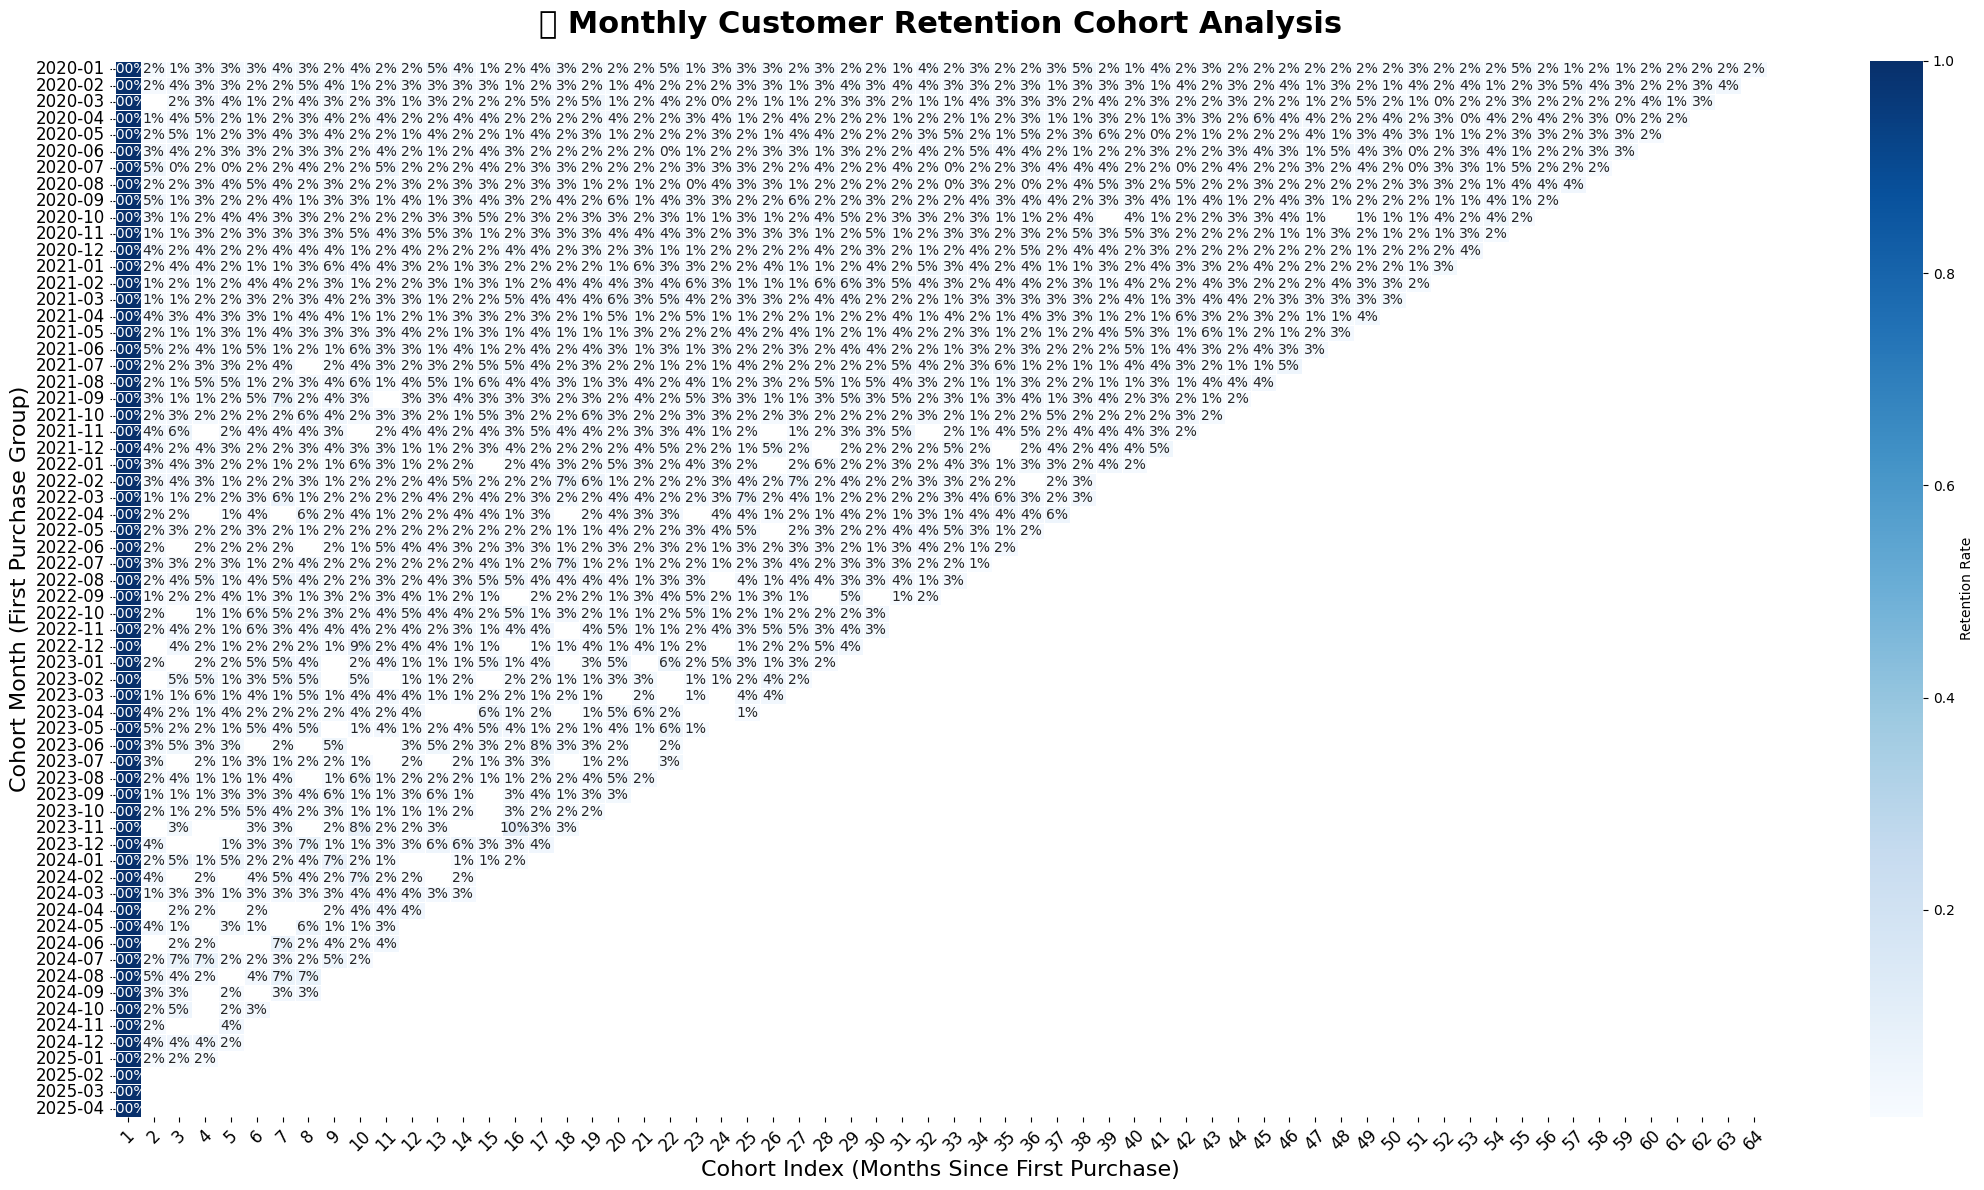

In [11]:
plt.figure(figsize=(22, 12))
sns.heatmap(
    retention_matrix,
    annot=True,             # Show cell values
    fmt=".0%",              # Format as percentage
    cmap="Blues",           # Better visual gradient
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Retention Rate'},
    square=False
)

plt.title('📊 Monthly Customer Retention Cohort Analysis', fontsize=22, fontweight='bold', pad=20)
plt.xlabel('Cohort Index (Months Since First Purchase)', fontsize=16)
plt.ylabel('Cohort Month (First Purchase Group)', fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
total_customers = df['customer_id'].nunique()
total_orders = df['order_id'].nunique()
total_revenue = df[df['payment_status'] == 'completed']['payment_amount'].sum()
total_payments = payments_df['payment_id'].nunique()
average_order_value = df['order_amount'].mean()
average_retention_rate = retention_matrix.iloc[:, 1:].mean().mean()

print("KPI Metrics for Dashboard:")
print(f"Total Customers: {total_customers}")
print(f"Total Orders: {total_orders}")
print(f"Total Revenue (Completed Payments): ${total_revenue:.2f}")
print(f"Total Payments Made: {total_payments}")
print(f"Average Order Value: ${average_order_value:.2f}")
print(f"Average Retention Rate (Month 2+): {average_retention_rate:.2%}")

KPI Metrics for Dashboard:
Total Customers: 7334
Total Orders: 15000
Total Revenue (Completed Payments): $1257085.15
Total Payments Made: 15000
Average Order Value: $253.73
Average Retention Rate (Month 2+): 2.61%
